In [ ]:
!pip install git+https://github.com/andreinechaev/nvcc4jupyter.git
%load_ext nvcc4jupyter

  Cloning https://github.com/andreinechaev/nvcc4jupyter.git to /tmp/pip-req-build-11yqh7xn
  Running command git clone --filter=blob:none --quiet https://github.com/andreinechaev/nvcc4jupyter.git /tmp/pip-req-build-11yqh7xn
  Resolved https://github.com/andreinechaev/nvcc4jupyter.git to commit 28f872a2f99a1b201bcd0db14fdbc5a496b9bfd7
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for nvcc4jupyter: filename=nvcc4jupyter-1.2.1-py3-none-any.whl size=10741 sha256=90a829d54142cdbaf5703d6409de30ec0002408286cfbcd108dfdd84cf0ee4fe
  Stored in directory: /tmp/pip-ephem-wheel-cache-99pi6vfy/wheels/7d/b9/66/459b9938664e6a93d1a85323ec52f7e51cd7265d253410a7d8
Successfully built nvcc4jupyter
Detected platform "Colab". Running its setup...
Source files will be saved in "/tmp/tmp14gnaa_o".


In [ ]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving image.jpg to image.jpg


In [ ]:
import os
print(os.getcwd())

!ls

/content
image.jpg  sample_data


In [ ]:
import cv2
image = cv2.imread('/content/image.jpg')
if image is None:
    print("Error")
else:
    print("Image read successfully")

Image read successfully


In [ ]:
%%writefile sobelEdgeDetectionFilter.cu
#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <cuda_runtime.h>
#include <opencv2/opencv.hpp>

using namespace cv;

__global__ void sobelFilter(unsigned char *srcImage, unsigned char *dstImage,
                            unsigned int width, unsigned int height) {

    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;

    if (x >= 1 && x < width-1 && y >= 1 && y < height-1) {

        int Gx[3][3] = {{-1,0,1},{-2,0,2},{-1,0,1}};
        int Gy[3][3] = {{1,2,1},{0,0,0},{-1,-2,-1}};

        int sumX = 0;
        int sumY = 0;

        for(int i=-1;i<=1;i++){
            for(int j=-1;j<=1;j++){
                unsigned char pixel = srcImage[(y+i)*width + (x+j)];
                sumX += pixel * Gx[i+1][j+1];
                sumY += pixel * Gy[i+1][j+1];
            }
        }

        int magnitude = sqrtf(sumX*sumX + sumY*sumY);
        magnitude = min(max(magnitude,0),255);

        dstImage[y*width + x] = (unsigned char)magnitude;
    }
}

void checkCudaErrors(cudaError_t r) {
    if (r != cudaSuccess) {
        fprintf(stderr, "CUDA Error: %s\n", cudaGetErrorString(r));
        exit(EXIT_FAILURE);
    }
}

int main() {

    Mat image = imread("/content/image.jpg", IMREAD_GRAYSCALE);

    if (image.empty()) {
        printf("Error: Image not found.\n");
        return -1;
    }

    int width = image.cols;
    int height = image.rows;

    size_t imageSize = width * height * sizeof(unsigned char);

    unsigned char *h_outputImage = (unsigned char*)malloc(imageSize);

    unsigned char *d_inputImage, *d_outputImage;

    checkCudaErrors(cudaMalloc(&d_inputImage,imageSize));
    checkCudaErrors(cudaMalloc(&d_outputImage,imageSize));

    checkCudaErrors(cudaMemcpy(d_inputImage,
                               image.data,
                               imageSize,
                               cudaMemcpyHostToDevice));

    dim3 blockSize(16,16);
    dim3 gridSize((width+15)/16,(height+15)/16);

    sobelFilter<<<gridSize,blockSize>>>(d_inputImage,d_outputImage,width,height);

    checkCudaErrors(cudaMemcpy(h_outputImage,
                               d_outputImage,
                               imageSize,
                               cudaMemcpyDeviceToHost));

    Mat outputImage(height,width,CV_8UC1,h_outputImage);

    imwrite("output_sobel.jpeg",outputImage);

    printf("Edge detection completed.\n");

    return 0;
}

Overwriting sobelEdgeDetectionFilter.cu


In [ ]:
!apt-get update
!apt-get install -y libopencv-dev

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [87.4 kB]
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,452 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:9 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,935 kB]
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy

In [ ]:
!ls /usr/include/opencv4/opencv2

alphamat.hpp	  highgui.hpp		   saliency.hpp
aruco		  imgcodecs		   shape
aruco.hpp	  imgcodecs.hpp		   shape.hpp
barcode.hpp	  img_hash		   stereo
bgsegm.hpp	  img_hash.hpp		   stereo.hpp
bioinspired	  imgproc		   stitching
bioinspired.hpp   imgproc.hpp		   stitching.hpp
calib3d		  intensity_transform.hpp  structured_light
calib3d.hpp	  line_descriptor	   structured_light.hpp
ccalib		  line_descriptor.hpp	   superres
ccalib.hpp	  mcc			   superres.hpp
core		  mcc.hpp		   surface_matching
core_detect.hpp   ml			   surface_matching.hpp
core.hpp	  ml.hpp		   text
datasets	  objdetect		   text.hpp
dnn		  objdetect.hpp		   tracking
dnn.hpp		  opencv.hpp		   tracking.hpp
dnn_superres.hpp  opencv_modules.hpp	   video
dpm.hpp		  optflow		   video.hpp
face		  optflow.hpp		   videoio
face.hpp	  phase_unwrapping	   videoio.hpp
features2d	  phase_unwrapping.hpp	   videostab
features2d.hpp	  photo			   videostab.hpp
flann		  photo.hpp		   viz
flann.hpp	  plot.hpp		   viz.hpp
freetype.hpp	  quality	

In [ ]:
!nvcc sobelEdgeDetectionFilter.cu -o sobel \
-I/usr/include/opencv4 \
-lopencv_core -lopencv_imgcodecs -lopencv_imgproc

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
/usr/include/opencv4/opencv2/stitching/detail/warpers.hpp(235): warning #611-D: overloaded virtual function "cv::detail::PlaneWarper::buildMaps" is only partially overridden in class "cv::detail::AffineWarper"
  class AffineWarper : public PlaneWarper
        ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

/usr/include/opencv4/opencv2/stitching/detail/warpers.hpp(235): warning #611-D: overloaded virtual function "cv::detail::PlaneWarper::warp" is only partially overridden in class "cv::detail::AffineWarper"
  class AffineWarper : public PlaneWarper
        ^

/usr/include/opencv4/opencv2/stitching/detail/blenders.hpp(100): warning #611-D: overloaded virtual function "cv::detail::Blender::prepare" is only partially overridden in class "cv::detail::FeatherBlender"
  clas

In [ ]:
!./sobel

Edge detection completed.


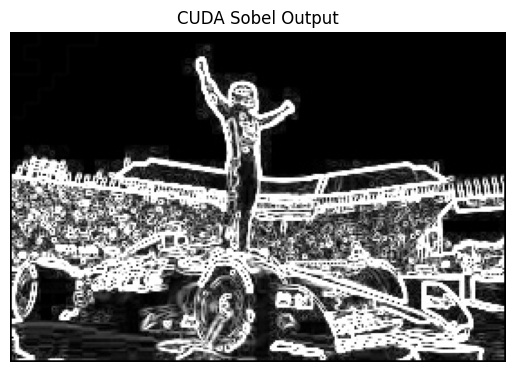

In [ ]:
import cv2
from matplotlib import pyplot as plt

img = cv2.imread('output_sobel.jpeg', 0)
plt.imshow(img, cmap='gray')
plt.title("CUDA Sobel Output")
plt.axis('off')
plt.show()